# [LAB 10] 2-2 결과 보고 모듈화
## 01. 준비작업
### 1. 라이브러리 참조

In [32]:
from hossam import load_data
from helpers import *
from pandas import DataFrame
from IPython.display import Markdown, display

### 2. 데이터 가져오기 및 전처리

In [33]:
origin = load_data('iris_bin')

# 종속변수 라벨링(versicolor = 0, virdinica = 1)
df = my_prep.labeling(origin, columns=['Species'])
df.head()

📚 아이리스 데이터셋을 이진분류 예제용으로 종속변수의 종류를 2개로 변경한 데이터 (Kaggle의 데이터셋을 직접 수정함)

    field         description
--  ------------  ----------------------------
 0  Sepal_Length  꽃받침 길이
 1  Sepal_Width   꽃받침 너비
 2  Petal_Length  꽃잎 길이
 3  Petal_Width   꽃잎 너비
 4  Species       품종 (versicolor, virginica)

Species (2종): versicolor=0, virginica=1


,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,7.000,3.200,4.700,1.400,0
1,6.400,3.200,4.500,1.500,0
2,6.900,3.100,4.900,1.500,0
3,5.500,2.300,4.000,1.300,0
4,6.500,2.800,4.600,1.500,0


### 3. 단순 로지스틱 회귀 모형 적합
- 이 결과에서 모형 적합도에 필요한 정보를 추출하고 오즈를 계산해야 한다.

In [34]:
data1 = df[['Sepal_Length', 'Species']]
fit1 = my_logit.fit_model(data1, y='Species', summary=True)

                           Logit Regression Results                           
Dep. Variable:                Species   No. Observations:                  100
Model:                          Logit   Df Residuals:                       98
Method:                           MLE   Df Model:                            1
Date:                Mon, 20 Jul 2026   Pseudo R-squ.:                  0.2026
Time:                        12:25:30   Log-Likelihood:                -55.273
converged:                       True   LL-Null:                       -69.315
Covariance Type:            nonrobust   LLR p-value:                 1.162e-07
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -12.5708      2.907     -4.325      0.000     -18.268      -6.873
Sepal_Length     2.0129      0.465      4.325      0.000       1.101       2.925


## #02. 모둘화 기능확인
### 1. 모형 적합도

In [35]:
display(Markdown(my_logit.report_fitness(fit1)))

**Note. n = 100. LL = -55.273, LL-Null = -69.315, LLR X²(1) = 28.083, p < 0.001, Pseudo R² = 0.203**

Species를 종속변수로, Sepal_Length(을)를 독립변수로 한 이항 로지스틱 회귀분석 결과, 모형은 통계적으로 유의하였다.

> LLR X²(1) = 28.083, p < 0.001 , Pseudo R² = 0.203.

즉, 모형의 유사결정계수는 0.203로 매우 우수한 적합수준을 보였다.

> ※Pseudo R²는 선형회귀의 R²처럼 '분산 설명 비율'로 해석하지 않는다. 일반적으로 **0.2~0.4** 구간이면 매우 우수한 적합으로 본다.

### 2. 오즈비 보고표
- 회귀계수, 오즈비, 95% 신뢰구간, VIF를 하나의 표로 정리한다.(단순모형이라 변수는 하나다.)

In [36]:
my_logit.report_variables(fit1, data1)

,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Species,Sepal_Length,2.013,1.334,0.465,4.325,0.000,7.485,3.006,18.637,1.000,1.000


### 3. 해석 문장 자동 생성

In [37]:
display(Markdown(my_logit.report_variables_text(fit1, data1)))

- **Sepal_Length**의 회귀계수는 **B = 2.0129**, 오즈비는 **OR = 7.4852**로 나타났으며, 이는 **Species**에 유의한 요인임을 의미한다. (**z = 4.32**, **p < .001**) 즉, **Sepal_Length**가 1 증가할 때 Species가 1(사건 발생)이 될 오즈는 평균적으로 약 **648.5% 증가**하는 것으로 해석된다. 

> ※ 오즈비(OR)가 1보다 크면 사건 발생 오즈가 증가, 1보다 작으면 감소함을 뜻한다. 유의확률이 유의수준보다 큰(=유의하지 않은) 변수는 효과가 통계적으로 확인되지 않았으므로 오즈비 해석에 주의한다. 더미변수의 오즈비는 '기준(drop_first로 제외된) 범주' 대비 값이다. 

### 4. 오즈비 시각화
- 오즈비를 가로 막대로 그린다.
- OR = 1 기준선을 넘는지가 핵심이다.

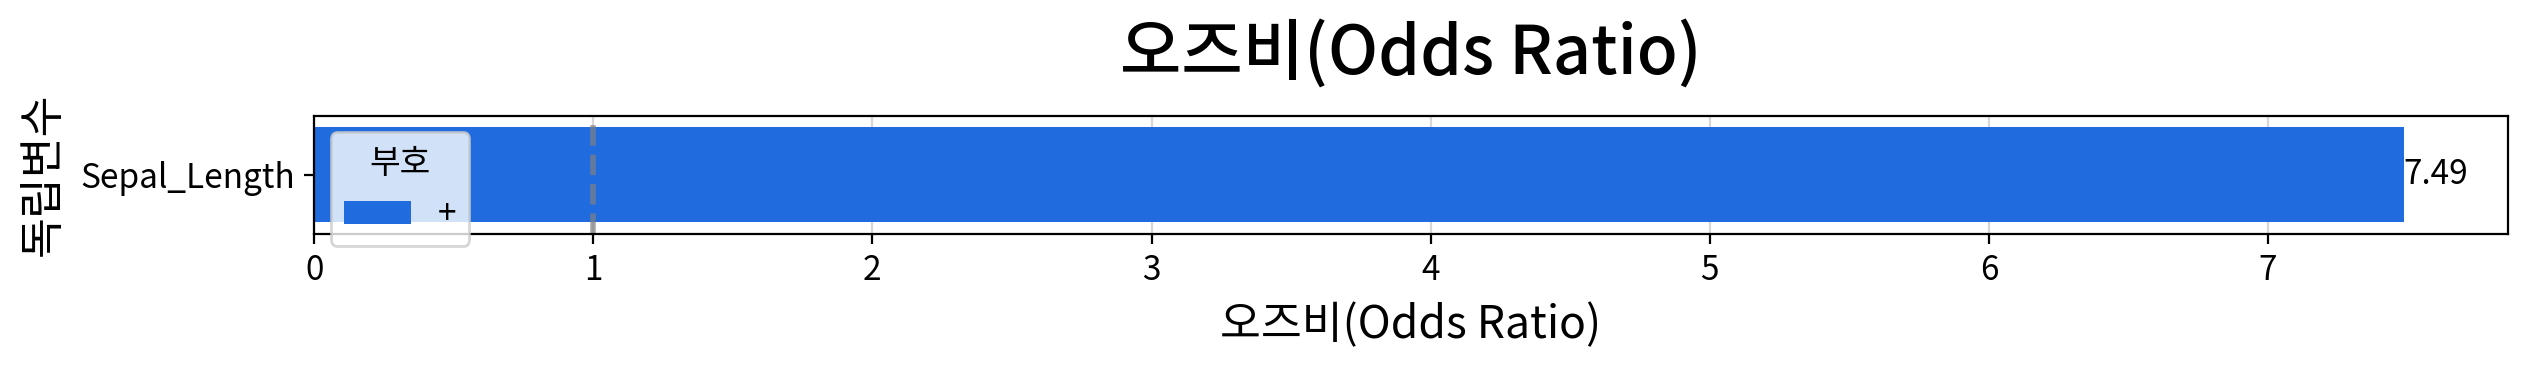

In [38]:
my_logit.plot_odds(fit1, data1, title='오즈비(Odds Ratio)', height=200)

## #연습문제
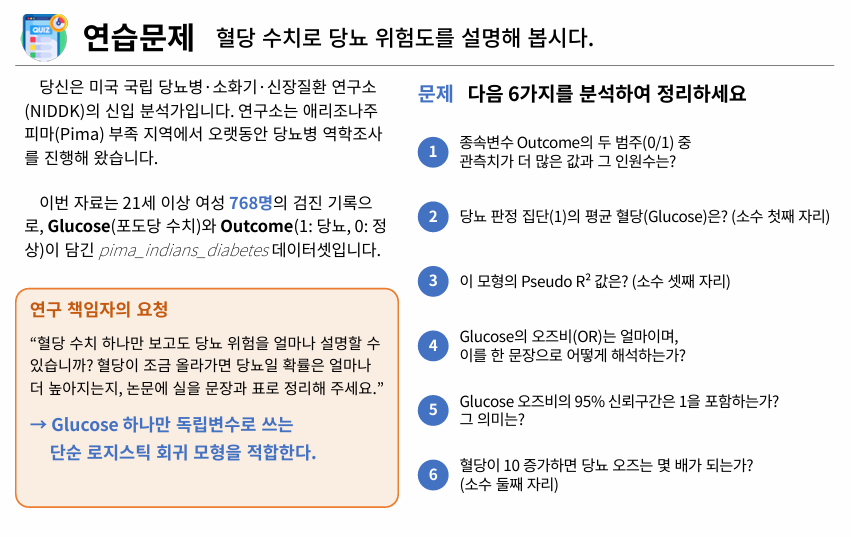

In [39]:
df1 = load_data('pima_indians_diabetes')
df1.head()

📚 이 데이터 세트는 원래 미국 국립 당뇨병·소화기·신장질환 연구소(National Institute of Diabetes and Digestive and Kidney Diseases)에서 제공한 것입니다. 이 데이터 세트의 목적은 데이터 세트에 포함된 특정 진단 측정값을 기반으로 환자의 당뇨병 여부를 진단적으로 예측하는 것입니다. 더 큰 데이터베이스에서 이러한 사례를 선택하는 데에는 몇 가지 제약 조건이 적용되었습니다. 특히, 여기에 포함된 모든 환자는 21세 이상의 피마 인디언 혈통을 가진 여성입니다. (출처: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

field                     type    description
------------------------  ------  --------------------------------
Pregnancies               연속형  임신횟수
Glucose                   연속형  포도당 부하 검사 수치
BloodPressure             연속형  혈압
SkinThickness             연속형  팔 삼두근 뒤쪽의 피하지방 측정값
Insulin                   연속형  혈청 인슐린
BMI                       연속형  체질량 지수
DiabetesPedigreeFunction  연속형  당뇨 내력 가중치 값
Age                       연속형  나이
Outcome                   명목형  당뇨여부(0 또는 1)



,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1


In [45]:
# 단순 로지스틱 → 독립변수는 Glucose 하나, 종속변수는 Outcome
data2 = df1[['Glucose', 'Outcome']]
fit2 = my_logit.fit_model(data2, y='Outcome', summary=True)

                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  768
Model:                          Logit   Df Residuals:                      766
Method:                           MLE   Df Model:                            1
Date:                Mon, 20 Jul 2026   Pseudo R-squ.:                  0.1860
Time:                        12:26:15   Log-Likelihood:                -404.36
converged:                       True   LL-Null:                       -496.74
Covariance Type:            nonrobust   LLR p-value:                 4.418e-42
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.3501      0.421    -12.713      0.000      -6.175      -4.525
Glucose        0.0379      0.003     11.647      0.000       0.031       0.044


In [46]:
# 문제 1번. 종속변수 Outcome의 두 범주(0/1) 중 관측치가 더 많은 값과 그 인원수는? > 0(정상) : 500명

df1['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [47]:
# 문제 2번. 당뇨 판정 집단(1)의 평균 혈당은? 1 : 141.3
df1.groupby('Outcome')['Glucose'].mean().round(1)

Outcome
0   110.000
1   141.300
Name: Glucose, dtype: float64

In [ ]:
# 문제 3번 이 모형의 Pseudo R제곱의 값은? > 0.186
display(Markdown(my_logit.report_fitness(fit2)))

**Note. n = 768. LL = -404.36, LL-Null = -496.742, LLR X²(1) = 184.764, p < 0.001, Pseudo R² = 0.186**

Outcome를 종속변수로, Glucose(을)를 독립변수로 한 이항 로지스틱 회귀분석 결과, 모형은 통계적으로 유의하였다.

> LLR X²(1) = 184.764, p < 0.001 , Pseudo R² = 0.186.

즉, 모형의 유사결정계수는 0.186로 양호한 적합수준을 보였다.

> ※Pseudo R²는 선형회귀의 R²처럼 '분산 설명 비율'로 해석하지 않는다. 일반적으로 **0.2~0.4** 구간이면 매우 우수한 적합으로 본다.

In [ ]:
# 문제 4번 > 1.0386, 즉, Glucose가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 3.9% 증가하는 것으로 해석된다
my_logit.report_variables(fit2, data2)                          # OR, 신뢰구간, VIF 표
display(Markdown(my_logit.report_variables_text(fit2, data2)))  # "1 증가할 때 오즈 약 X% 증가" 문장

- **Glucose**의 회귀계수는 **B = 0.0379**, 오즈비는 **OR = 1.0386**로 나타났으며, 이는 **Outcome**에 유의한 요인임을 의미한다. (**z = 11.65**, **p < .001**) 즉, **Glucose**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **3.9% 증가**하는 것으로 해석된다. 

> ※ 오즈비(OR)가 1보다 크면 사건 발생 오즈가 증가, 1보다 작으면 감소함을 뜻한다. 유의확률이 유의수준보다 큰(=유의하지 않은) 변수는 효과가 통계적으로 확인되지 않았으므로 오즈비 해석에 주의한다. 더미변수의 오즈비는 '기준(drop_first로 제외된) 범주' 대비 값이다. 

In [ ]:
# 문제 5번  > 신뢰구간 1을 포함하지 않음. 오즈비의 신뢰구간 하한이 1보다 크므로 Glucose이 Outcome에 사건 발생 오즈가 증가하여 통계적으로 유의한 요인임을 의미한다.
my_logit.report_variables(fit2, data2)


,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Outcome,Glucose,0.038,1.211,0.003,11.647,0.000,1.039,1.032,1.045,1.000,1.000


In [56]:
display(Markdown(my_logit.report_variables_text(fit2, data2)))

- **Glucose**의 회귀계수는 **B = 0.0379**, 오즈비는 **OR = 1.0386**로 나타났으며, 이는 **Outcome**에 유의한 요인임을 의미한다. (**z = 11.65**, **p < .001**) 즉, **Glucose**가 1 증가할 때 Outcome가 1(사건 발생)이 될 오즈는 평균적으로 약 **3.9% 증가**하는 것으로 해석된다. 

> ※ 오즈비(OR)가 1보다 크면 사건 발생 오즈가 증가, 1보다 작으면 감소함을 뜻한다. 유의확률이 유의수준보다 큰(=유의하지 않은) 변수는 효과가 통계적으로 확인되지 않았으므로 오즈비 해석에 주의한다. 더미변수의 오즈비는 '기준(drop_first로 제외된) 범주' 대비 값이다. 

In [ ]:
# 문제 6번 > 1.46
B = fit2.params['Glucose']
import numpy as np
OR = np.exp(B)
print(round(OR ** 10, 2)) 

1.46
